# Binary Classification Mini-Project

Dataset setup for the Breast Cancer Wisconsin (Diagnostic) binary classification task.

## Dataset and Train-Test Split

We use `sklearn.datasets.load_breast_cancer`, which contains 569 samples with 30 real-valued features derived from digitised FNA biopsy images. The original sklearn target uses `0 = malignant` and `1 = benign`, so we remap it to match the assignment convention: `1 = malignant` and `0 = benign`.

All experiments use an 80/20 stratified train-test split with `random_state=42`.

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

In [2]:
breast_cancer = load_breast_cancer()

X = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names,
)

# sklearn encodes malignant as 0 and benign as 1. The assignment expects
# malignant = 1 and benign = 0, so invert the sklearn target.
y = pd.Series(1 - breast_cancer.target, name="malignant")

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Class counts:")
print(y.value_counts().sort_index().rename(index={0: "benign", 1: "malignant"}))
# print breast_cancer 3 rows with feature names and target values
print("\nSample data:")
print(pd.concat([X, y], axis=1).head(3))

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class counts:
malignant
benign       357
malignant    212
Name: count, dtype: int64

Sample data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 455 samples
Test set: 114 samples


In [4]:
split_summary = pd.DataFrame(
    {
        "train_count": y_train.value_counts().sort_index(),
        "train_fraction": y_train.value_counts(normalize=True).sort_index(),
        "test_count": y_test.value_counts().sort_index(),
        "test_fraction": y_test.value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "benign", 1: "malignant"})

split_summary

,train_count,train_fraction,test_count,test_fraction
malignant,,,,
benign,285,0.626374,72,0.631579
malignant,170,0.373626,42,0.368421


## L2-Regularised Logistic Regression

We fit logistic regression with L2 regularisation. The inverse regularisation strength `C` is selected using 5-fold stratified cross-validation on the training set only. Features are standardised inside the pipeline before fitting so that coefficient magnitudes are comparable across features.

In [5]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C_GRID = np.logspace(-4, 4, 17)

l2_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=C_GRID,
        cv=5,
        penalty="l2",
        scoring="accuracy",
        solver="lbfgs",
        max_iter=10_000,
        random_state=RANDOM_STATE,
    ),
)

l2_logreg.fit(X_train, y_train)

logreg_model = l2_logreg.named_steps["logisticregressioncv"]
best_c = float(logreg_model.C_[0])
coefficients = pd.Series(
    logreg_model.coef_.ravel(),
    index=X_train.columns,
    name="coefficient",
)

coefficient_table = coefficients.to_frame()
coefficient_table["abs_coefficient"] = coefficient_table["coefficient"].abs()
coefficient_table = coefficient_table.sort_values("abs_coefficient", ascending=False)

top_five_features = coefficient_table.head(5)

print(f"Best C from 5-fold CV: {best_c:g}")
print("\nLearned coefficient vector (standardised feature scale):")
print(coefficients.to_string())
print("\nFive most influential features by |w_j|:")
print(top_five_features)


Best C from 5-fold CV: 3.16228

Learned coefficient vector (standardised feature scale):
mean radius                0.163365
mean texture               0.302134
mean perimeter             0.182990
mean area                  0.384127
mean smoothness            0.501305
mean compactness          -1.091155
mean concavity             1.165834
mean concave points        1.472044
mean symmetry             -0.405945
mean fractal dimension     0.282763
radius error               2.050871
texture error             -0.837988
perimeter error            1.098838
area error                 1.505861
smoothness error           0.414698
compactness error         -1.377701
concavity error           -0.393278
concave points error       0.960949
symmetry error            -0.664072
fractal dimension error   -0.807286
worst radius               1.147324
worst texture              2.192046
worst perimeter            0.824763
worst area                 1.276103
worst smoothness           0.187897
worst compa

## Class-Conditional Gaussian Models: LDA vs QDA

We fit Gaussian class-conditional models by maximum likelihood on the training set. LDA uses one shared covariance matrix across the two classes, while QDA estimates a separate covariance matrix for each class. The reported training log-likelihood is the labelled joint log-likelihood, $\sum_i \log p(y_i) + \log p(x_i \mid y_i)$, using maximum-likelihood class priors, means, and covariance matrices.

In [6]:
import warnings

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from scipy.linalg import LinAlgWarning


def mle_class_priors(y, classes):
    y_array = np.asarray(y)
    return np.array([(y_array == cls).mean() for cls in classes])


def mle_class_means(X, y, classes):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)
    return np.vstack([X_array[y_array == cls].mean(axis=0) for cls in classes])


def mle_covariances(X, y, classes, means, shared):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)

    if shared:
        scatter = np.zeros((X_array.shape[1], X_array.shape[1]))
        for class_index, cls in enumerate(classes):
            centered = X_array[y_array == cls] - means[class_index]
            scatter += centered.T @ centered
        return scatter / X_array.shape[0]

    covariances = []
    for class_index, cls in enumerate(classes):
        centered = X_array[y_array == cls] - means[class_index]
        covariances.append(centered.T @ centered / centered.shape[0])
    return covariances


def gaussian_logpdf(X, mean, covariance):
    X_array = np.asarray(X, dtype=float)
    covariance = np.asarray(covariance, dtype=float)
    sign, logdet = np.linalg.slogdet(covariance)
    if sign <= 0:
        covariance = covariance + 1e-8 * np.eye(covariance.shape[0])
        sign, logdet = np.linalg.slogdet(covariance)

    centered = X_array - mean
    solved = np.linalg.solve(covariance, centered.T).T
    quadratic_form = np.sum(centered * solved, axis=1)
    n_features = X_array.shape[1]
    return -0.5 * (n_features * np.log(2 * np.pi) + logdet + quadratic_form)


def labelled_gaussian_log_likelihood(X, y, classes, priors, means, covariances, shared):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)
    total = 0.0

    for class_index, cls in enumerate(classes):
        class_mask = y_array == cls
        covariance = covariances if shared else covariances[class_index]
        total += np.sum(
            np.log(priors[class_index])
            + gaussian_logpdf(X_array[class_mask], means[class_index], covariance)
        )

    return float(total)


lda = LinearDiscriminantAnalysis(solver="lsqr", store_covariance=True)
qda = QuadraticDiscriminantAnalysis(store_covariance=True)

lda.fit(X_train, y_train)
with warnings.catch_warnings(record=True) as qda_warnings:
    warnings.simplefilter("always", LinAlgWarning)
    qda.fit(X_train, y_train)

classes = lda.classes_
priors = mle_class_priors(y_train, classes)
means = mle_class_means(X_train, y_train, classes)
lda_covariance = mle_covariances(X_train, y_train, classes, means, shared=True)
qda_covariances = mle_covariances(X_train, y_train, classes, means, shared=False)

lda_log_likelihood = labelled_gaussian_log_likelihood(
    X_train,
    y_train,
    classes,
    priors,
    means,
    lda_covariance,
    shared=True,
)
qda_log_likelihood = labelled_gaussian_log_likelihood(
    X_train,
    y_train,
    classes,
    priors,
    means,
    qda_covariances,
    shared=False,
)

log_likelihood_summary = pd.DataFrame(
    {
        "model": ["LDA", "QDA"],
        "covariance_assumption": ["shared covariance", "class-specific covariances"],
        "n_covariance_matrices": [1, len(classes)],
        "training_log_likelihood": [lda_log_likelihood, qda_log_likelihood],
    }
)

print(log_likelihood_summary.to_string(index=False))

if qda_log_likelihood > lda_log_likelihood:
    better_model = "QDA"
    reason = "it estimates a separate covariance matrix for each class, making the Gaussian model more flexible."
else:
    better_model = "LDA"
    reason = "the shared-covariance constraint gives the higher likelihood on this training split."

print(f"\nHigher training log-likelihood: {better_model}, because {reason}")
print(
    "This is an in-sample likelihood comparison: QDA's extra covariance parameters can improve "
    "training fit, but they also increase variance and overfitting risk."
)

if qda_warnings:
    print(
        "QDA also raised a covariance rank warning, which is plausible for this dataset because "
        "several features are strongly correlated; this makes the unregularised covariance estimates ill-conditioned."
    )


model      covariance_assumption  n_covariance_matrices  training_log_likelihood
  LDA          shared covariance                      1             14820.462741
  QDA class-specific covariances                      2             18067.407400

Higher training log-likelihood: QDA, because it estimates a separate covariance matrix for each class, making the Gaussian model more flexible.
This is an in-sample likelihood comparison: QDA's extra covariance parameters can improve training fit, but they also increase variance and overfitting risk.
QDA also raised a covariance rank warning, which is plausible for this dataset because several features are strongly correlated; this makes the unregularised covariance estimates ill-conditioned.


## Support Vector Machines

We train two SVM variants: a linear-kernel SVM and an RBF-kernel SVM. Hyperparameters are selected using 5-fold grid search on the training set. For visualisation, the training data are standardised and projected onto the first two principal components; support vectors selected by each fitted SVM are highlighted in that 2-D PCA plane.

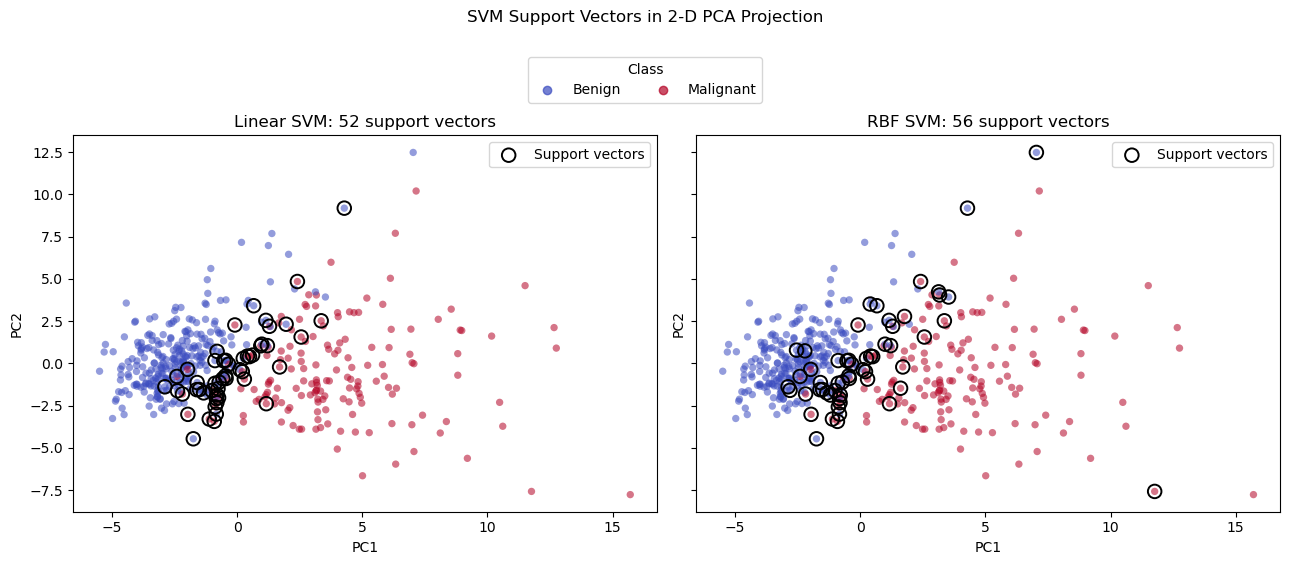

SVM grid-search summary:
kernel                          best_params  best_cv_accuracy  n_support_vectors  support_vectors_class_0  support_vectors_class_1
linear                      {'svc__C': 0.1}          0.967033                 52                       26                       26
   rbf {'svc__C': 10.0, 'svc__gamma': 0.01}          0.975824                 56                       29                       27

PCA explained variance ratio: PC1=0.446, PC2=0.185


In [7]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linear_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="linear")),
    param_grid={"svc__C": np.logspace(-3, 3, 7)},
    cv=svm_cv,
    scoring="accuracy",
)

rbf_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="rbf")),
    param_grid={
        "svc__C": np.logspace(-3, 3, 7),
        "svc__gamma": np.logspace(-4, 1, 6),
    },
    cv=svm_cv,
    scoring="accuracy",
)

linear_svm_grid.fit(X_train, y_train)
rbf_svm_grid.fit(X_train, y_train)

linear_svm = linear_svm_grid.best_estimator_.named_steps["svc"]
rbf_svm = rbf_svm_grid.best_estimator_.named_steps["svc"]

svm_summary = pd.DataFrame(
    {
        "kernel": ["linear", "rbf"],
        "best_params": [linear_svm_grid.best_params_, rbf_svm_grid.best_params_],
        "best_cv_accuracy": [linear_svm_grid.best_score_, rbf_svm_grid.best_score_],
        "n_support_vectors": [linear_svm.support_.size, rbf_svm.support_.size],
        "support_vectors_class_0": [linear_svm.n_support_[0], rbf_svm.n_support_[0]],
        "support_vectors_class_1": [linear_svm.n_support_[1], rbf_svm.n_support_[1]],
    }
)

pca_scaler = StandardScaler()
X_train_scaled = pca_scaler.fit_transform(X_train)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
svm_models = [
    ("Linear SVM", linear_svm),
    ("RBF SVM", rbf_svm),
]

for ax, (title, model) in zip(axes, svm_models):
    scatter = ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train,
        cmap="coolwarm",
        alpha=0.55,
        s=28,
        edgecolors="none",
    )
    support_indices = model.support_
    ax.scatter(
        X_train_pca[support_indices, 0],
        X_train_pca[support_indices, 1],
        facecolors="none",
        edgecolors="black",
        s=95,
        linewidths=1.4,
        label="Support vectors",
    )
    ax.set_title(f"{title}: {support_indices.size} support vectors")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

handles, labels = scatter.legend_elements(prop="colors", alpha=0.7)
fig.legend(
    handles,
    ["Benign", "Malignant"],
    title="Class",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.04),
)
fig.suptitle("SVM Support Vectors in 2-D PCA Projection", y=1.12)
fig.tight_layout()
plt.show()

print("SVM grid-search summary:")
print(svm_summary.to_string(index=False))
print(
    f"\nPCA explained variance ratio: PC1={pca_2d.explained_variance_ratio_[0]:.3f}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.3f}"
)


## Decision Tree

We fit an unpruned decision tree first, then use a stratified validation split from the training data to study pre-pruning with `max_depth` from 1 to 20. The final pruned tree uses the shallowest depth that attains the best validation accuracy, which keeps the visualisation interpretable for depth <= 5 on this split.


Unpruned decision tree:
Depth: 6
Leaves: 19
Training accuracy: 1.000
Validation accuracy: 0.912


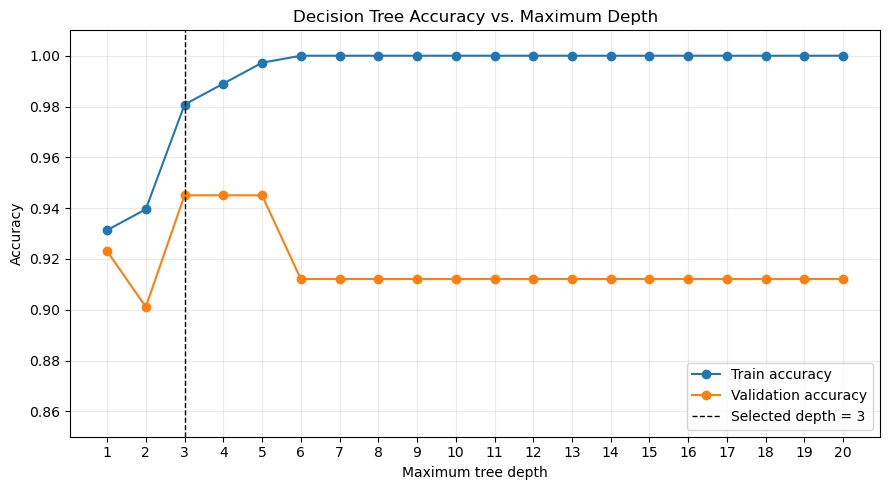


Depth sweep results:
 max_depth train_accuracy validation_accuracy  actual_depth  n_leaves
         1          0.931               0.923             1         2
         2          0.940               0.901             2         4
         3          0.981               0.945             3         8
         4          0.989               0.945             4        14
         5          0.997               0.945             5        18
         6          1.000               0.912             6        19
         7          1.000               0.912             6        19
         8          1.000               0.912             6        19
         9          1.000               0.912             6        19
        10          1.000               0.912             6        19
        11          1.000               0.912             6        19
        12          1.000               0.912             6        19
        13          1.000               0.912             6        1

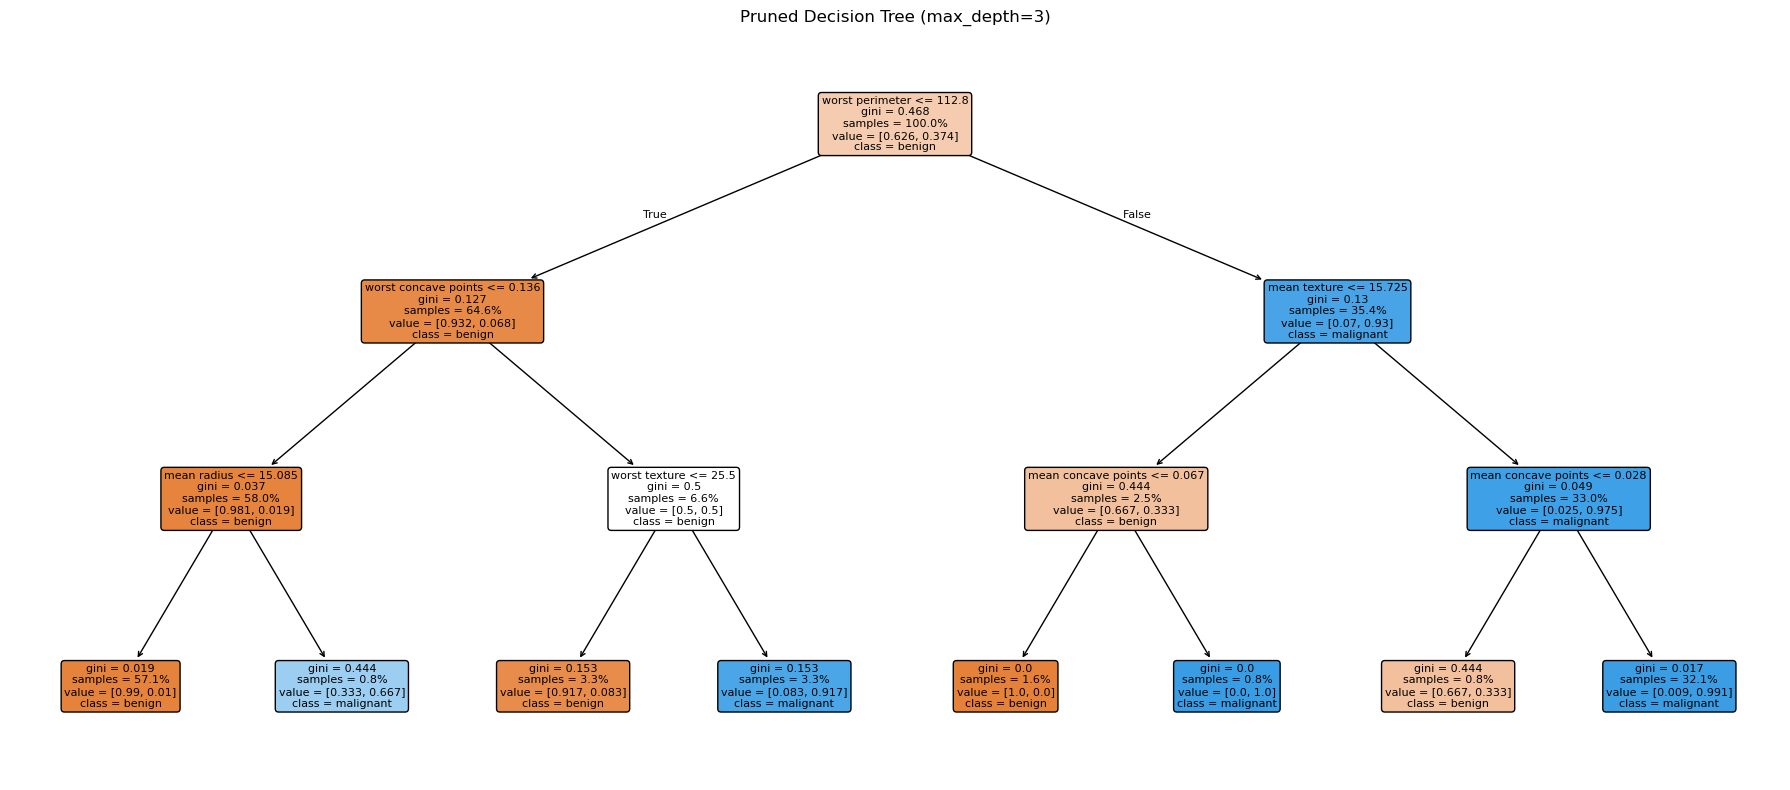


Gini-based feature importances for the final pruned tree:
                     gini_importance
worst perimeter               0.7831
worst concave points          0.0631
worst texture                 0.0527
mean texture                  0.0436
mean concave points           0.0413
mean radius                   0.0162


In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_tree_train, X_val, y_tree_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

unpruned_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
unpruned_tree.fit(X_tree_train, y_tree_train)

print("Unpruned decision tree:")
print(f"Depth: {unpruned_tree.get_depth()}")
print(f"Leaves: {unpruned_tree.get_n_leaves()}")
print(f"Training accuracy: {unpruned_tree.score(X_tree_train, y_tree_train):.3f}")
print(f"Validation accuracy: {unpruned_tree.score(X_val, y_val):.3f}")

max_depth_values = range(1, 21)
depth_results = []

for max_depth in max_depth_values:
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE)
    tree.fit(X_tree_train, y_tree_train)
    depth_results.append(
        {
            "max_depth": max_depth,
            "train_accuracy": tree.score(X_tree_train, y_tree_train),
            "validation_accuracy": tree.score(X_val, y_val),
            "actual_depth": tree.get_depth(),
            "n_leaves": tree.get_n_leaves(),
        }
    )

depth_scores = pd.DataFrame(depth_results)
best_depth = int(depth_scores.loc[depth_scores["validation_accuracy"].idxmax(), "max_depth"])

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
final_tree.fit(X_tree_train, y_tree_train)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depth_scores["max_depth"], depth_scores["train_accuracy"], marker="o", label="Train accuracy")
ax.plot(depth_scores["max_depth"], depth_scores["validation_accuracy"], marker="o", label="Validation accuracy")
ax.axvline(best_depth, color="black", linestyle="--", linewidth=1, label=f"Selected depth = {best_depth}")
ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree Accuracy vs. Maximum Depth")
ax.set_xticks(list(max_depth_values))
ax.set_ylim(0.85, 1.01)
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

print("\nDepth sweep results:")
print(depth_scores.to_string(index=False, formatters={
    "train_accuracy": "{:.3f}".format,
    "validation_accuracy": "{:.3f}".format,
}))
print(f"\nSelected pruned tree max_depth: {best_depth}")
print(f"Final tree depth: {final_tree.get_depth()}")
print(f"Final tree leaves: {final_tree.get_n_leaves()}")
print(f"Final tree training accuracy: {final_tree.score(X_tree_train, y_tree_train):.3f}")
print(f"Final tree validation accuracy: {final_tree.score(X_val, y_val):.3f}")

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    final_tree,
    feature_names=X_train.columns,
    class_names=["benign", "malignant"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=8,
    ax=ax,
)
ax.set_title(f"Pruned Decision Tree (max_depth={best_depth})")
fig.tight_layout()
plt.show()

feature_importances = (
    pd.Series(final_tree.feature_importances_, index=X_train.columns, name="gini_importance")
    .sort_values(ascending=False)
    .to_frame()
)
nonzero_feature_importances = feature_importances[feature_importances["gini_importance"] > 0]

print("\nGini-based feature importances for the final pruned tree:")
print(nonzero_feature_importances.to_string(formatters={"gini_importance": "{:.4f}".format}))


## Second Dataset: UCI Ionosphere

We repeat the modelling pipeline on the UCI Ionosphere dataset. The target is encoded as `1 = good radar return` and `0 = bad radar return`. One feature is constant in this dataset, so it is removed before modelling because it carries no discriminative information and can make covariance-based models unstable.


Ionosphere feature matrix shape after cleanup: (351, 33)
Removed zero-variance columns: ['feature_02']
Class counts:
good_radar_return
bad     126
good    225
Name: count, dtype: int64
Training set: 280 samples
Test set: 71 samples


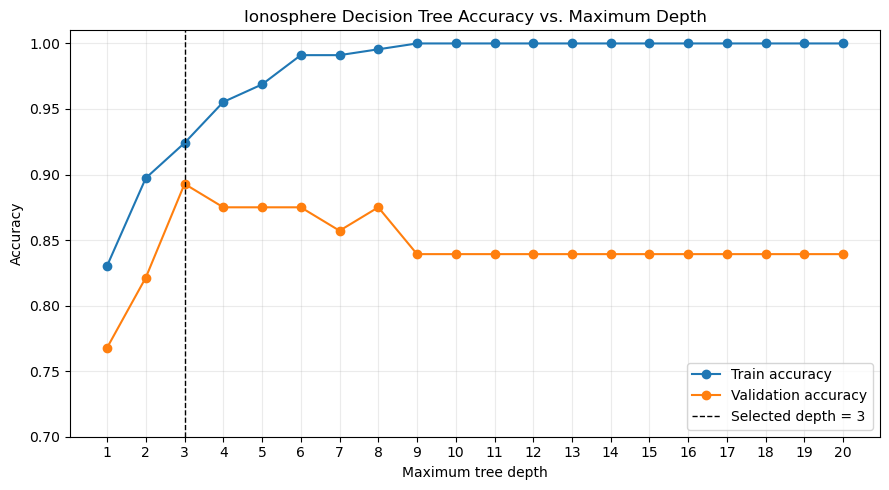


Ionosphere L2 logistic regression:
Best C from 5-fold CV: 3.16228
Five most influential features by |w_j|:
           abs_coefficient coefficient
feature_01          3.6514      3.6514
feature_22          2.1026     -2.1026
feature_30          1.6140      1.6140
feature_27          1.5143     -1.5143
feature_34          1.4771     -1.4771

Ionosphere SVM grid-search summary:
kernel                         best_params best_cv_accuracy test_accuracy
linear                     {'svc__C': 1.0}            0.886         0.887
   rbf {'svc__C': 10.0, 'svc__gamma': 0.1}            0.950         0.930

Ionosphere decision tree:
Unpruned depth: 9
Unpruned train accuracy: 1.000
Unpruned validation accuracy: 0.839
Selected pruned tree max_depth: 3
Final pruned test accuracy: 0.930

Depth sweep results:
 max_depth train_accuracy validation_accuracy  actual_depth  n_leaves
         1          0.830               0.768             1         2
         2          0.897               0.821            

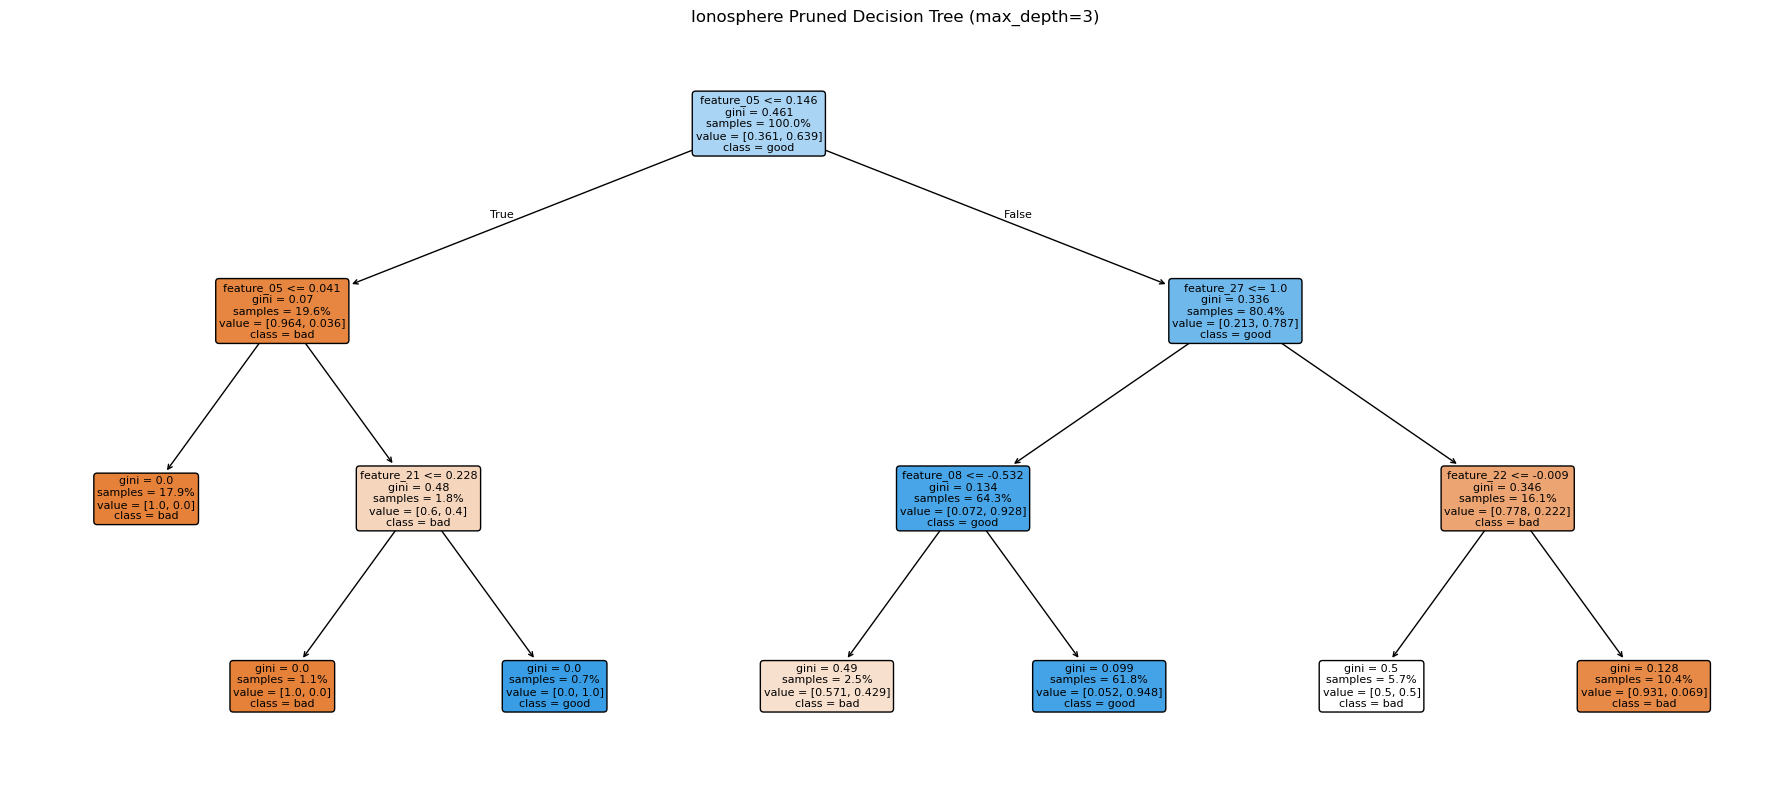


Ionosphere Gini-based feature importances for the final pruned tree:
           gini_importance
feature_05          0.5284
feature_27          0.3698
feature_22          0.0395
feature_08          0.0375
feature_21          0.0248

Held-out test accuracy comparison:
                method breast_cancer_test_accuracy ionosphere_test_accuracy  breast_cancer_rank  ionosphere_rank
                   QDA                       0.939                    0.944                   5                1
  Pruned Decision Tree                       0.904                    0.930                   6                2
               RBF SVM                       0.982                    0.930                   1                2
                   LDA                       0.965                    0.915                   3                4
L2 Logistic Regression                       0.965                    0.887                   3                5
            Linear SVM                       0.982    

In [9]:
from sklearn.metrics import accuracy_score

IONOSPHERE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
IONOSPHERE_COLUMNS = [f"feature_{idx:02d}" for idx in range(1, 35)] + ["class"]

ionosphere_df = pd.read_csv(IONOSPHERE_URL, header=None, names=IONOSPHERE_COLUMNS)
X_ionosphere = ionosphere_df.drop(columns="class")
y_ionosphere = ionosphere_df["class"].map({"b": 0, "g": 1}).rename("good_radar_return")

zero_variance_columns = X_ionosphere.columns[X_ionosphere.nunique() <= 1].tolist()
X_ionosphere = X_ionosphere.drop(columns=zero_variance_columns)

X_iono_train, X_iono_test, y_iono_train, y_iono_test = train_test_split(
    X_ionosphere,
    y_ionosphere,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_ionosphere,
)

print(f"Ionosphere feature matrix shape after cleanup: {X_ionosphere.shape}")
print(f"Removed zero-variance columns: {zero_variance_columns}")
print("Class counts:")
print(y_ionosphere.value_counts().sort_index().rename(index={0: "bad", 1: "good"}))
print(f"Training set: {X_iono_train.shape[0]} samples")
print(f"Test set: {X_iono_test.shape[0]} samples")

iono_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

iono_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=C_GRID,
        cv=iono_cv,
        penalty="l2",
        scoring="accuracy",
        solver="lbfgs",
        max_iter=10_000,
        random_state=RANDOM_STATE,
    ),
)
iono_logreg.fit(X_iono_train, y_iono_train)
iono_logreg_model = iono_logreg.named_steps["logisticregressioncv"]
iono_coefficients = pd.Series(
    iono_logreg_model.coef_.ravel(),
    index=X_iono_train.columns,
    name="coefficient",
)
iono_top_logreg_features = (
    iono_coefficients.abs()
    .sort_values(ascending=False)
    .head(5)
    .rename("abs_coefficient")
    .to_frame()
)
iono_top_logreg_features["coefficient"] = iono_coefficients.loc[iono_top_logreg_features.index]

iono_lda = LinearDiscriminantAnalysis(solver="lsqr")
# A small regularisation term is used because Ionosphere has many correlated features
# relative to the number of samples, which can make class covariance estimates singular.
iono_qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
iono_lda.fit(X_iono_train, y_iono_train)
iono_qda.fit(X_iono_train, y_iono_train)

iono_linear_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="linear")),
    param_grid={"svc__C": np.logspace(-3, 3, 7)},
    cv=iono_cv,
    scoring="accuracy",
)
iono_rbf_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="rbf")),
    param_grid={
        "svc__C": np.logspace(-3, 3, 7),
        "svc__gamma": np.logspace(-4, 1, 6),
    },
    cv=iono_cv,
    scoring="accuracy",
)
iono_linear_svm_grid.fit(X_iono_train, y_iono_train)
iono_rbf_svm_grid.fit(X_iono_train, y_iono_train)

X_iono_tree_train, X_iono_val, y_iono_tree_train, y_iono_val = train_test_split(
    X_iono_train,
    y_iono_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_iono_train,
)

iono_unpruned_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
iono_unpruned_tree.fit(X_iono_tree_train, y_iono_tree_train)

iono_depth_results = []
for max_depth in range(1, 21):
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE)
    tree.fit(X_iono_tree_train, y_iono_tree_train)
    iono_depth_results.append(
        {
            "max_depth": max_depth,
            "train_accuracy": tree.score(X_iono_tree_train, y_iono_tree_train),
            "validation_accuracy": tree.score(X_iono_val, y_iono_val),
            "actual_depth": tree.get_depth(),
            "n_leaves": tree.get_n_leaves(),
        }
    )

iono_depth_scores = pd.DataFrame(iono_depth_results)
iono_best_depth = int(iono_depth_scores.loc[iono_depth_scores["validation_accuracy"].idxmax(), "max_depth"])
iono_final_tree = DecisionTreeClassifier(max_depth=iono_best_depth, random_state=RANDOM_STATE)
iono_final_tree.fit(X_iono_train, y_iono_train)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iono_depth_scores["max_depth"], iono_depth_scores["train_accuracy"], marker="o", label="Train accuracy")
ax.plot(iono_depth_scores["max_depth"], iono_depth_scores["validation_accuracy"], marker="o", label="Validation accuracy")
ax.axvline(iono_best_depth, color="black", linestyle="--", linewidth=1, label=f"Selected depth = {iono_best_depth}")
ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Accuracy")
ax.set_title("Ionosphere Decision Tree Accuracy vs. Maximum Depth")
ax.set_xticks(list(range(1, 21)))
ax.set_ylim(0.70, 1.01)
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

print("\nIonosphere L2 logistic regression:")
print(f"Best C from 5-fold CV: {float(iono_logreg_model.C_[0]):g}")
print("Five most influential features by |w_j|:")
print(iono_top_logreg_features.to_string(formatters={
    "abs_coefficient": "{:.4f}".format,
    "coefficient": "{:.4f}".format,
}))

iono_svm_summary = pd.DataFrame(
    {
        "kernel": ["linear", "rbf"],
        "best_params": [iono_linear_svm_grid.best_params_, iono_rbf_svm_grid.best_params_],
        "best_cv_accuracy": [iono_linear_svm_grid.best_score_, iono_rbf_svm_grid.best_score_],
        "test_accuracy": [iono_linear_svm_grid.score(X_iono_test, y_iono_test), iono_rbf_svm_grid.score(X_iono_test, y_iono_test)],
    }
)

print("\nIonosphere SVM grid-search summary:")
print(iono_svm_summary.to_string(index=False, formatters={
    "best_cv_accuracy": "{:.3f}".format,
    "test_accuracy": "{:.3f}".format,
}))

print("\nIonosphere decision tree:")
print(f"Unpruned depth: {iono_unpruned_tree.get_depth()}")
print(f"Unpruned train accuracy: {iono_unpruned_tree.score(X_iono_tree_train, y_iono_tree_train):.3f}")
print(f"Unpruned validation accuracy: {iono_unpruned_tree.score(X_iono_val, y_iono_val):.3f}")
print(f"Selected pruned tree max_depth: {iono_best_depth}")
print(f"Final pruned test accuracy: {iono_final_tree.score(X_iono_test, y_iono_test):.3f}")
print("\nDepth sweep results:")
print(iono_depth_scores.to_string(index=False, formatters={
    "train_accuracy": "{:.3f}".format,
    "validation_accuracy": "{:.3f}".format,
}))

if iono_final_tree.get_depth() <= 5:
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_tree(
        iono_final_tree,
        feature_names=X_iono_train.columns,
        class_names=["bad", "good"],
        filled=True,
        rounded=True,
        impurity=True,
        proportion=True,
        fontsize=8,
        ax=ax,
    )
    ax.set_title(f"Ionosphere Pruned Decision Tree (max_depth={iono_best_depth})")
    fig.tight_layout()
    plt.show()
else:
    print("\nFinal pruned tree is deeper than 5, so it is not visualised inline.")

iono_tree_importances = (
    pd.Series(iono_final_tree.feature_importances_, index=X_iono_train.columns, name="gini_importance")
    .sort_values(ascending=False)
    .to_frame()
)
print("\nIonosphere Gini-based feature importances for the final pruned tree:")
print(iono_tree_importances[iono_tree_importances["gini_importance"] > 0].to_string(
    formatters={"gini_importance": "{:.4f}".format}
))

breast_cancer_comparison = pd.DataFrame(
    {
        "method": ["Linear SVM", "RBF SVM", "L2 Logistic Regression", "LDA", "QDA", "Pruned Decision Tree"],
        "test_accuracy": [0.982456, 0.982456, 0.964912, 0.964912, 0.938596, 0.903509],
    }
)

ionosphere_comparison = pd.DataFrame(
    {
        "method": [
            "L2 Logistic Regression",
            "LDA",
            "QDA",
            "Linear SVM",
            "RBF SVM",
            "Pruned Decision Tree",
        ],
        "test_accuracy": [
            iono_logreg.score(X_iono_test, y_iono_test),
            iono_lda.score(X_iono_test, y_iono_test),
            iono_qda.score(X_iono_test, y_iono_test),
            iono_linear_svm_grid.score(X_iono_test, y_iono_test),
            iono_rbf_svm_grid.score(X_iono_test, y_iono_test),
            iono_final_tree.score(X_iono_test, y_iono_test),
        ],
    }
).sort_values("test_accuracy", ascending=False)

comparison_table = (
    breast_cancer_comparison.rename(columns={"test_accuracy": "breast_cancer_test_accuracy"})
    .merge(
        ionosphere_comparison.rename(columns={"test_accuracy": "ionosphere_test_accuracy"}),
        on="method",
    )
)
comparison_table["breast_cancer_rank"] = comparison_table["breast_cancer_test_accuracy"].rank(
    method="min", ascending=False
).astype(int)
comparison_table["ionosphere_rank"] = comparison_table["ionosphere_test_accuracy"].rank(
    method="min", ascending=False
).astype(int)
comparison_table = comparison_table.sort_values(["ionosphere_rank", "method"])

print("\nHeld-out test accuracy comparison:")
print(comparison_table.to_string(index=False, formatters={
    "breast_cancer_test_accuracy": "{:.3f}".format,
    "ionosphere_test_accuracy": "{:.3f}".format,
}))

print("\nRanking comment:")
print(
    "The relative ranking changes. On Breast Cancer, the SVMs are best on the held-out split, "
    "followed by logistic regression/LDA, then QDA and the pruned tree. On Ionosphere, QDA is best, "
    "RBF SVM and the pruned tree are close behind, and the linear models fall lower. This suggests "
    "Ionosphere benefits more from nonlinear or class-specific covariance structure than the Breast "
    "Cancer split does."
)
